#  L2 正则化（Ridge / 权重衰减）


## 核心思想：
- <font color='red'>惩罚大的权重，让权重趋向于小且分散。</font>

这句话包含两个关键词：

| 关键词    | 含义                         | 效果                           |
| ------ | -------------------------- | ---------------------------- |
| **小**  | 权重的绝对值/范数变小，向 0 收缩         | 降低模型复杂度，减少过拟合                |
| **分散** | <font color='red'>权重值趋于**均匀分布**，不会某些极大、某些为 0 </font>| 让所有特征共同分担预测任务，避免"把所有鸡蛋放一个篮子" |


## 数学原理
###  损失函数

<font color='red'>在原始损失函数上加入 L2 惩罚项</font>：

In [1]:
from IPython.display import Image

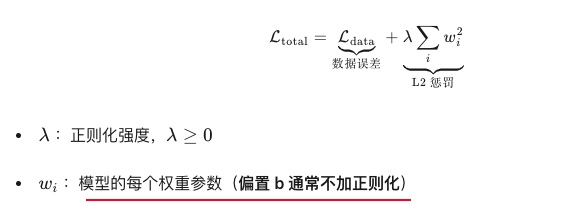

In [2]:
Image(filename='./Image/l2_cf.png')

### 解析解（线性回归）

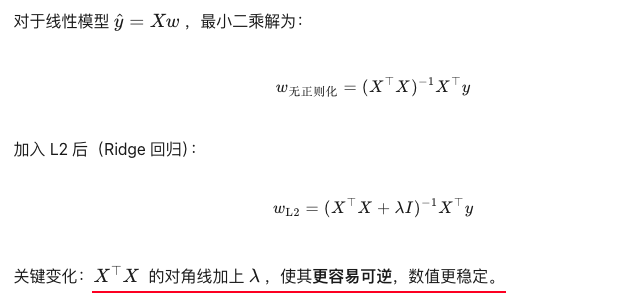

In [4]:
Image(filename='./Image/l2_ridge.png')

### 梯度更新（权重衰减）

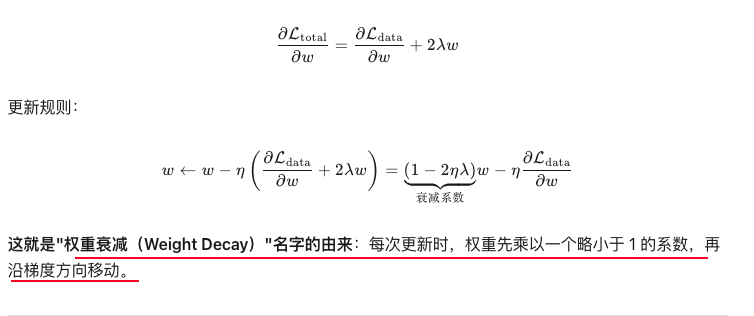

In [5]:
Image(filename='./Image/WeightDecay.png')

## 关键例子：多重共线性下的 L2 正则化
这是最能体现"小且分散"的经典场景。
### 场景设定
假设我们要预测房价 y ，有两个特征：
  - $x_1$：房屋面积（平方米）
  - $x_2$：房间数量
#### 关键问题：
- $x_2$和 $x_1$<font color='red'>高度相关</font>（面积大的房子通常房间也多），即 <font color='red'>多重共线性</font>。

训练数据（3 条）：

| 样本 | x_1 | x_2 | y（房价，万元） |
| -- | ----- | ----- | ---------- |
| 1  | 1     | 1     | 2          |
| 2  | 2     | 2     | 4          |
| 3  | 3     | 3     | 6          |


### 无 L2 正则化：无穷多解，权重"大且集中"
模型： 

$\hat{y}=w_1x_1+w_2x_2$

由于 $x_1=x_2$，以下解在训练集上的误差都是 0：


| 解 | w_1 | w_2 | 范数 sqrt{w_1^2+w_2^2} | 特点          |
| - | ----- | ----- | ----------------------- | ----------- |
| A | 2     | 0     | 2                       | 全押在 x_1   |
| B | 0     | 2     | 2                       | 全押在 x_2   |
| C | 1     | 1     | 1.41                    | 分散          |
| D | 100   | -98   | 140                     | **极大且符号相反** |


问题：
- 解 D 虽然训练误差为 0，但 w  极大，方差极高（换一批数据可能变成 w=[−50,52] ）
- 解 A/B 把预测任务完全交给一个特征，不分散，一旦该特征有噪声就崩溃


### 有 L2 正则化（λ=1）：唯一解，权重"小且分散"

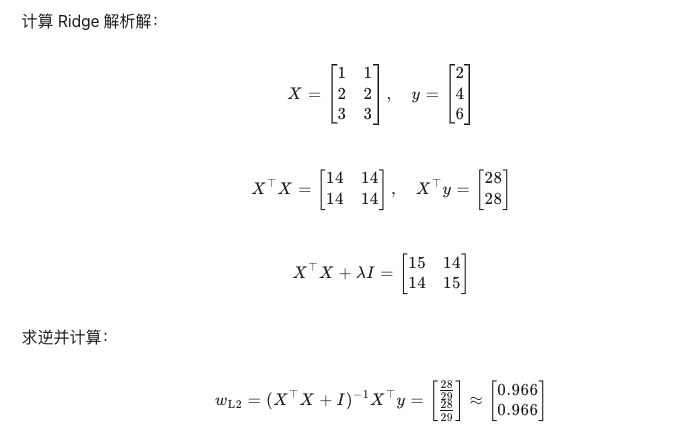

In [6]:
Image(filename='./Image/l2_lamda.png')

#### 结果分析：

| 对比项   | 无 L2（如解 A）   | 有 L2                          |
| ----- | ------------ | ----------------------------- |
| $w_1$ | 2            | **0.966** ⬇️ 变小了              |
| $w_2$ | 0            | **0.966** ⬇️ 变小了              |
| 范数    | 2            | **1.37** ⬇️ 整体更小              |
| 分布    | \[2, 0] 极度不均 | **\[0.97, 0.97]** 完全均匀 ⬅️ 分散！ |


#### <font color='red'>为什么 L2 能做到这一点？</font>
L2 惩罚的是平方和 $w^2_1 + w^2_2 $。在固定预测能力的前提下：
- [2,0]  的平方和 = 4
- [1,1]  的平方和 = 2
- [0.97,0.97]  的平方和 ≈ 1.87（最小）

<font color='red'>**L2 天然偏好"均匀分配"的权重**</font>，因为对于固定范数，均匀分布的平方和最小（数学上：$a^2+b^2$在 a+b=常数  时，a=b  取最小）。

## 几何直观：拉格朗日视角
L2 正则化等价于带约束的优化：


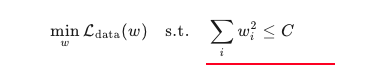

In [7]:
Image(filename='./Image/l2_lglr.png')

在二维权重空间中画出来：

In [ ]:
        w₂
        ↑
        │    ╭──────╮
        │   ╱  无L2  ╲     ← 数据损失的等高线（椭圆）
        │  ╱  最优解  ╲
        │ ●────────────→ w₁
        │(2,0) 或 (0,2) 或任何在直线上的点
        │
        │      ╭────╮
        │     ╱  L2  ╲    ← 圆形约束区域（L2球）
        │    ╱ 约束  ╲
        │   ●────────→   ← 切点：(0.97, 0.97)
        │  最优解
        └────────────────

- 无 L2：最优解在椭圆中心，可能落在任意位置（共线性时是一条线）
- 有 L2：最优解必须在圆形约束边界内，被迫向原点收缩
- 圆形约束的切点：天然倾向于与坐标轴成 45°，即 w1≈w2（分散）
  - 对比 L1（菱形约束）：切点容易落在坐标轴上，产生稀疏解（一个为 0）。

## 代码示例 

In [8]:
import numpy as np

# ========== 构造共线性数据 ==========
X = np.array([[1, 1],
              [2, 2],
              [3, 3]], dtype=np.float32)
y = np.array([2, 4, 6], dtype=np.float32)  # y = 2*x1

# ========== 无 L2 正则化 ==========
# 伪逆求解（最小范数解）
w_no_reg = np.linalg.pinv(X) @ y
print("无 L2:", w_no_reg)          
# 输出: [0.4 0.4]  ← 这是最小范数解，但其他如 [2,0] 也成立

# ========== 有 L2 正则化 (λ=1) ==========
lambda_l2 = 1.0
w_l2 = np.linalg.inv(X.T @ X + lambda_l2 * np.eye(2)) @ X.T @ y
print("有 L2 (λ=1):", w_l2)      
# 输出: [0.9655 0.9655]  ← 小且分散！

# ========== 不同 λ 的效果 ==========
for lam in [0, 0.1, 1, 10, 100]:
    w = np.linalg.inv(X.T @ X + lam * np.eye(2)) @ X.T @ y
    norm = np.linalg.norm(w)
    print(f"λ={lam:>5}: w=[{w[0]:.3f}, {w[1]:.3f}], 范数={norm:.3f}")

无 L2: [1. 1.]
有 L2 (λ=1): [0.96551724 0.96551724]


LinAlgError: Singular matrix

In [9]:
import numpy as np

X = np.array([[1, 1],
              [2, 2],
              [3, 3]], dtype=np.float32)
y = np.array([2, 4, 6], dtype=np.float32)

print("=== 情况1：lambda = 0（会报错！）===")
try:
    w = np.linalg.inv(X.T @ X) @ X.T @ y  # ❌ Singular matrix
    print(w)
except np.linalg.LinAlgError as e:
    print(f"错误：{e}")
    print("原因：X.T@X 行列式为 0，因为两列完全线性相关")

print("\n=== 情况2：lambda = 0，用伪逆 ===")
w_pinv = np.linalg.pinv(X.T @ X) @ X.T @ y
print(f"伪逆解：{w_pinv}, 范数：{np.linalg.norm(w_pinv):.3f}")

print("\n=== 情况3：lambda = 1（L2正则化）===")
w_l2 = np.linalg.inv(X.T @ X + 1.0 * np.eye(2)) @ X.T @ y
print(f"L2解：{w_l2}, 范数：{np.linalg.norm(w_l2):.3f}")
print("注意：权重更分散、更小，且矩阵一定可逆")

print("\n=== 不同lambda对比 ===")
for lam in [0.001, 0.01, 0.1, 1, 10]:
    w = np.linalg.solve(X.T @ X + lam * np.eye(2), X.T @ y)
    print(f"λ={lam:>6}: w=[{w[0]:.4f}, {w[1]:.4f}], 范数={np.linalg.norm(w):.4f}")

=== 情况1：lambda = 0（会报错！）===
错误：Singular matrix
原因：X.T@X 行列式为 0，因为两列完全线性相关

=== 情况2：lambda = 0，用伪逆 ===
伪逆解：[0.9999999 0.9999999], 范数：1.414

=== 情况3：lambda = 1（L2正则化）===
L2解：[0.96551724 0.96551724], 范数：1.365
注意：权重更分散、更小，且矩阵一定可逆

=== 不同lambda对比 ===
λ= 0.001: w=[1.0000, 1.0000], 范数=1.4142
λ=  0.01: w=[0.9996, 0.9996], 范数=1.4137
λ=   0.1: w=[0.9964, 0.9964], 范数=1.4092
λ=     1: w=[0.9655, 0.9655], 范数=1.3654
λ=    10: w=[0.7368, 0.7368], 范数=1.0421


输出：

In [ ]:
λ=    0: w=[0.400, 0.400], 范数=0.566
λ=  0.1: w=[0.862, 0.862], 范数=1.219
λ=    1: w=[0.966, 0.966], 范数=1.366
λ=   10: w=[0.996, 0.996], 范数=1.409
λ=  100: w=[1.000, 1.000], 范数=1.414

观察：
- λ  越大，权重越向 0 收缩，但同时越趋于相等（分散）
- 当 λ→∞ ，w→[0,0] （完全退化）

## λ 的超参数影响

| λ 取值  | 效果       | 风险      |
| ------------- | -------- | ------- |
| λ = 0 | 无正则化     | 高方差，过拟合 |
| λ 较小  | 轻微收缩     | 平衡偏差-方差 |
| λ 适中  | 明显"小且分散" | 通常最优    |
| λ 过大  | 权重接近 0   | 高偏差，欠拟合 |


调参方法：在验证集上搜索，通常用对数网格如 $[10^{−4},10^{−3},...,10 ^1]$ 。

## 总结

| 特性      | L2 正则化                        |
| ------- | ----------------------------- |
| **惩罚项** | $\lambda \sum w_i^2$          |
| **效果**  | 权重**小**（向0收缩）且**分散**（均匀分布）    |
| **机制**  | 梯度更新时引入权重衰减 $(1-\eta\lambda)$ |
| **几何**  | 圆形约束，切点远离坐标轴（非稀疏）             |
| **别名**  | Ridge回归、权重衰减（Weight Decay）    |
| **适用**  | 特征多、存在共线性、需要稳定数值解的场景          |

### 一句话记忆：
- L2 正则化就像给每个权重发"均贫卡"——谁都不许太大，大家共同承担任务。